In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
coverage_data = pd.read_csv(f'../metric/metrics_100_high_d.csv', header=None)
coverage_data.columns = ['path', 'coverage', 'feature']
coverage_data.head(10)

,path,coverage,feature
0,bace-sf-random-100-9.npy,8.053070e+05,78.819347
1,bace-al_adaptive-medoids-knn-cluster_margin-10...,7.779956e+05,79.142817
2,bace-al_adaptive-max_entropy-knn-pareto-100-2.npy,9.085529e+05,80.796410
3,bace-al_adaptive-random-gp-pareto-100-9.npy,9.642024e+05,80.900966
4,bace-al_adaptive-random-knn-topk-100-7.npy,1.027614e+06,78.946268
5,bace-al_adaptive-medoids-knn-pareto-100-9.npy,7.571658e+05,80.912152
6,bace-al_adaptive-max_entropy-gp_ard-pareto-100...,8.455365e+05,80.924331
7,bace-al_adaptive-maximin-gp_ard-pareto-100-0.npy,1.013471e+06,81.682429
8,bace-al_adaptive-medoids-gp-cluster_margin-100...,6.518858e+05,79.120890
9,bace-al_adaptive-max_entropy-knn-cluster_margi...,7.389985e+05,78.952384


In [3]:
# Convert raw data into usable format.
coverage_dict = {
    'task': [],
    'strategy': [],
    'sampler': [],
    'model': [],
    'batch_strat': [],
    'size': [],
    'seed': [],
    'coverage': [],
    'feature': []
}
for iter, row in coverage_data.iterrows():
    vals = row['path'][:-4].split('-')

    # Active learning algorithm.
    if len(vals) == 7:
        coverage_dict['task'].append(vals[0])
        coverage_dict['strategy'].append(vals[1])
        coverage_dict['sampler'].append(vals[2])
        coverage_dict['model'].append(vals[3])
        coverage_dict['batch_strat'].append(vals[4])
        coverage_dict['size'].append(int(vals[5]))
        coverage_dict['seed'].append(int(vals[6]))
        coverage_dict['coverage'].append(row['coverage'])
        coverage_dict['feature'].append(row['feature'])

    elif vals[1] == 'sf':
        coverage_dict['task'].append(vals[0])
        coverage_dict['strategy'].append(vals[1])
        coverage_dict['sampler'].append(vals[2])
        coverage_dict['model'].append('none')
        coverage_dict['batch_strat'].append('none')
        coverage_dict['size'].append(int(vals[3]))
        coverage_dict['seed'].append(int(vals[4]))
        coverage_dict['coverage'].append(row['coverage'])
        coverage_dict['feature'].append(row['feature'])


    # Adaptive space-filling algorithm.
    else:
        coverage_dict['task'].append(vals[0])
        coverage_dict['strategy'].append(vals[1])
        coverage_dict['sampler'].append('none')
        coverage_dict['model'].append('none')
        coverage_dict['batch_strat'].append('none')
        coverage_dict['size'].append(int(vals[2]))
        coverage_dict['seed'].append(int(vals[3]))
        coverage_dict['coverage'].append(row['coverage'])
        coverage_dict['feature'].append(row['feature'])


coverage_df = pd.DataFrame(coverage_dict)

# Due to numerical issues, remove rc and semiconductor.
coverage_df = coverage_df[(coverage_df['task'] != 'rc') & (coverage_df['task'] != 'semiconductor')]
coverage_df.head(10)

,task,strategy,sampler,model,batch_strat,size,seed,coverage,feature
0,bace,sf,random,none,none,100,9,8.053070e+05,78.819347
1,bace,al_adaptive,medoids,knn,cluster_margin,100,6,7.779956e+05,79.142817
2,bace,al_adaptive,max_entropy,knn,pareto,100,2,9.085529e+05,80.796410
3,bace,al_adaptive,random,gp,pareto,100,9,9.642024e+05,80.900966
4,bace,al_adaptive,random,knn,topk,100,7,1.027614e+06,78.946268
5,bace,al_adaptive,medoids,knn,pareto,100,9,7.571658e+05,80.912152
6,bace,al_adaptive,max_entropy,gp_ard,pareto,100,4,8.455365e+05,80.924331
7,bace,al_adaptive,maximin,gp_ard,pareto,100,0,1.013471e+06,81.682429
8,bace,al_adaptive,medoids,gp,cluster_margin,100,6,6.518858e+05,79.120890
9,bace,al_adaptive,max_entropy,knn,cluster_margin,100,3,7.389985e+05,78.952384


In [4]:
results = pd.read_csv('../survey/results/results_100_full.csv', index_col=0)
column_names = ['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed', 'Size']
for model in ['rf', 'gbt', 'sv', 'nn', 'gp', 'gp_ard', 'knn']:
    for metric in ['r2', 'mae', 'rmse', 'rel_rmse', 'pearson', 'spearman']:
        column_names.append(f'{model}-{metric}')
results.columns = column_names
results.head(10)

# Due to numerical issues, remove rc and semiconductor.
results = results[(results['Task'] != 'rc') & (results['Task'] != 'semiconductor')]
datasets = results['Task'].unique()

In [5]:
METRIC = 'spearman'
metric_columns = [name for name in column_names if METRIC in name]
initial_columns = ['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed']
included_columns = [*initial_columns, *metric_columns]
task_results = results[included_columns]
task_results_long = task_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_name',
    value_name='metric_value'
)
task_results_long['Predictor'] = task_results_long['metric_name'].str.replace(f'-{METRIC}$', '', regex=True)
task_results_long.head(10)
task_performances = task_results_long.loc[:,['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed', 'Predictor', 'metric_value']]
task_performances = task_performances.groupby(by='Task')['metric_value'].agg(['mean']).reset_index()
task_performances = task_performances.sort_values(by='mean', ascending=False)
task_performances = task_performances[(task_performances['mean'] > 0.1)]
intermediate_tasks = task_performances['Task'].to_list()

print(f'Intermediate tasks considered: {len(intermediate_tasks)}')

Intermediate tasks considered: 49


In [6]:
# Compute aggregate rankings based on coverage.
average_results = coverage_df[coverage_df['task'].isin(intermediate_tasks)]

norm_factors = average_results.groupby(['task', 'strategy', 'sampler', 'model', 'batch_strat'])['coverage'].mean().reset_index()
norm_factors = norm_factors.groupby('task')['coverage'].min().reset_index()
norm_factors = norm_factors.set_index('task')['coverage'].to_dict()
average_results['coverage_norm'] = average_results.loc[:,'coverage'] / average_results['task'].map(norm_factors)

norm_factors = average_results.groupby(['task', 'strategy', 'sampler', 'model', 'batch_strat'])['feature'].mean().reset_index()
norm_factors = norm_factors.groupby('task')['feature'].min().reset_index()
norm_factors = norm_factors.set_index('task')['feature'].to_dict()
average_results['feature_norm'] = average_results.loc[:,'feature'] / average_results['task'].map(norm_factors)

average_results = average_results[['strategy', 'sampler', 'model', 'batch_strat', 'coverage_norm', 'feature_norm']]
average_results_grouped = average_results.groupby(['strategy', 'sampler', 'model', 'batch_strat'])
coverage_results_agg = average_results_grouped[['coverage_norm', 'feature_norm']].agg(['mean', 'sem']).reset_index()
coverage_results_agg.columns = ['Strategy', 'Sampler', 'Model', 'Batch', 'coverage-mean', 'coverage-sem', 'feature-mean', 'feature-sem']
coverage_results_agg.head(10)

/var/folders/53/ykyq1mvs00s7ftzjkmf_97q0mgtbtw/T/ipykernel_98428/665301824.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  average_results['coverage_norm'] = average_results.loc[:,'coverage'] / average_results['task'].map(norm_factors)
/var/folders/53/ykyq1mvs00s7ftzjkmf_97q0mgtbtw/T/ipykernel_98428/665301824.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  average_results['feature_norm'] = average_results.loc[:,'feature'] / average_results['task'].map(norm_factors)


,Strategy,Sampler,Model,Batch,coverage-mean,coverage-sem,feature-mean,feature-sem
0,al_adaptive,max_entropy,gp,cluster_margin,1.505718,0.034374,1.021721,0.004483
1,al_adaptive,max_entropy,gp,hallucinate,1.786005,0.032950,1.041062,0.005078
2,al_adaptive,max_entropy,gp,pareto,1.690808,0.021979,1.038265,0.004515
3,al_adaptive,max_entropy,gp,topk,4.736124,0.830515,1.042285,0.005292
4,al_adaptive,max_entropy,gp_ard,cluster_margin,1.506181,0.034476,1.021787,0.004496
5,al_adaptive,max_entropy,gp_ard,hallucinate,1.792721,0.033404,1.041676,0.005163
6,al_adaptive,max_entropy,gp_ard,pareto,1.688679,0.021664,1.037615,0.004428
7,al_adaptive,max_entropy,gp_ard,topk,4.717391,0.828168,1.042098,0.005279
8,al_adaptive,max_entropy,knn,cluster_margin,5.235637,1.145173,1.010067,0.002049
9,al_adaptive,max_entropy,knn,hallucinate,7.014164,1.515652,1.019140,0.003200


In [7]:
# Get average Spearman rank correlations across datasets.
METRIC = 'spearman'
included_columns = [name for name in column_names if METRIC in name]
included_columns.insert(0, 'Seed')
included_columns.insert(0, 'Batch')
included_columns.insert(0, 'Model')
included_columns.insert(0, 'Sampler')
included_columns.insert(0, 'Strategy')
included_columns.insert(0, 'Task')
average_results = results[included_columns]
average_results.head(20)

average_results_long = average_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_full',
    value_name='metric_value'
)
average_results_long['Predictor'] = average_results_long['metric_full'].str.replace(f'-{METRIC}$', '', regex=True)
average_results_long.head(10)

average_results_long = average_results_long[average_results_long['Task'].isin(intermediate_tasks)]

# NOTE: We are considering a subset of predictors...
# average_results_long = average_results_long[average_results_long['Predictor'] == 'knn']

norm_factors = average_results_long.groupby(['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Predictor'])['metric_value'].mean().reset_index()
if METRIC in ['r2', 'spearman', 'pearson']:
    norm_factors = norm_factors.groupby('Task')['metric_value'].max().reset_index()
else:
    norm_factors = norm_factors.groupby('Task')['metric_value'].min().reset_index()
norm_factors = norm_factors.set_index('Task')['metric_value'].to_dict()
average_results_long['score_norm'] = average_results_long['metric_value'] / average_results_long['Task'].map(norm_factors)

average_results_long = average_results_long[['Strategy', 'Sampler', 'Model', 'Batch', 'Predictor', 'score_norm']]
average_results_grouped = average_results_long.groupby(['Strategy', 'Sampler', 'Model', 'Batch'])
average_results_agg = average_results_grouped['score_norm'].agg(['mean', 'sem']).reset_index()
if METRIC in ['pearson', 'spearman']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=False)
if METRIC in ['mae', 'rel_rmse']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=True)

# if METRIC in ['mae', 'rel_rmse']:
#     cutoff = average_results_agg.iloc[0,4] + average_results_agg.iloc[0,5]
#     average_results_agg['lower'] = average_results_agg['mean'] - average_results_agg['sem']
#     average_results_agg = average_results_agg[average_results_agg['lower'] < cutoff]
# else:
#     cutoff = average_results_agg.iloc[0,4] - average_results_agg.iloc[0,5]
#     average_results_agg['upper'] = average_results_agg['mean'] + average_results_agg['sem']
#     average_results_agg = average_results_agg[average_results_agg['upper'] > cutoff]

average_results_agg.columns = ['Strategy', 'Sampler', 'Model', 'Batch', 'metric-mean', 'metric-sem']
average_results_agg.head(10)

,Strategy,Sampler,Model,Batch,metric-mean,metric-sem
98,sf,medoids,none,none,0.916231,0.002635
12,al_adaptive,max_entropy,nn,cluster_margin,0.909440,0.002925
100,sf_adaptive,none,none,none,0.907485,0.002506
0,al_adaptive,max_entropy,gp,cluster_margin,0.902783,0.002743
4,al_adaptive,max_entropy,gp_ard,cluster_margin,0.902778,0.002743
84,al_adaptive,random,nn,cluster_margin,0.901628,0.003093
60,al_adaptive,medoids,nn,cluster_margin,0.899433,0.003174
99,sf,random,none,none,0.899196,0.002782
52,al_adaptive,medoids,gp_ard,cluster_margin,0.898179,0.002902
48,al_adaptive,medoids,gp,cluster_margin,0.895303,0.002995


In [8]:
# Merge tables of metrics.
merged = coverage_results_agg.merge(
    average_results_agg,
    on=['Strategy', 'Sampler', 'Model', 'Batch']
)
merged.head(10)
merged.to_csv('./data/feature_coverage_data.csv')

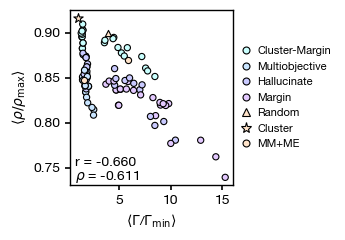

In [9]:
# Visualize correlation between coverage and performance.
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
fig, ax = plt.subplots(1,1,figsize=(3.5,2.5))

random_idx = -1
cluster_idx = -1
adaptive_idx = -1
maximin_idx = -1
al_colors = []
for iter, row in merged.iterrows():
    if 'cluster_margin' in row['Batch']:
        al_colors.append("#C9FFFE")
    elif 'pareto' in row['Batch']:
        al_colors.append("#C9E5FF")
    elif 'hallucinate' in row['Batch']:
        al_colors.append("#C9CAFF")
    elif 'topk' in row['Batch']:
        al_colors.append("#E3C9FF")
    elif row['Strategy'] == 'sf' and row['Sampler'] == 'random':
        random_idx = iter
    elif row['Strategy'] == 'sf' and row['Sampler'] == 'medoids':
        cluster_idx = iter
    elif row['Strategy'] == 'sf_adaptive':
        adaptive_idx = iter
    elif row['Strategy'] == 'sf' and row['Sampler'] == 'maximin':
        maximin_idx = iter

# Plot AL algorithms.
ax.scatter(merged[merged['Strategy'] == 'al_adaptive']['coverage-mean'], merged[merged['Strategy'] == 'al_adaptive']['metric-mean'], s=20, color=al_colors, edgecolors='black', linewidth=0.8, zorder=5)

# Plot SF algorithms.
ax.scatter(
    merged[(merged['Strategy'] == 'sf') & ((merged['Sampler'] == 'maximin') | (merged['Sampler'] == 'max_entropy'))]['coverage-mean'], 
    merged[(merged['Strategy'] == 'sf') & ((merged['Sampler'] == 'maximin') | (merged['Sampler'] == 'max_entropy'))]['metric-mean'], 
    s=20, color='#FFE3C9', edgecolors='black', linewidth=0.8, zorder=10
)

# Plot random selection.
ax.scatter(
    merged.iloc[random_idx]['coverage-mean'],
    merged.iloc[random_idx]['metric-mean'],
    marker='^',
    s=20, color='#FFE3C9', edgecolors='black', linewidth=0.8, zorder=10,
)

# Plot cluster selection.
ax.scatter(
    merged.iloc[cluster_idx]['coverage-mean'],
    merged.iloc[cluster_idx]['metric-mean'],
    marker='*',
    s=50, color='#FFE3C9', edgecolors='black', linewidth=0.8, zorder=10,
)

# ax.scatter(
#     merged.iloc[maximin_idx]['coverage-mean'],
#     merged.iloc[maximin_idx]['metric-mean'],
#     marker='o',
#     s=30, color='#FFFFC9', edgecolors='black', linewidth=0.8, zorder=10,
# )

# Plot adaptive space-filling.
# ax.scatter(
#     merged.iloc[adaptive_idx]['coverage-mean'],
#     merged.iloc[adaptive_idx]['metric-mean'],
#     marker='s',
#     s=40, color='#FFE3C9', edgecolors='black', linewidth=0.8, zorder=10,
# )

from matplotlib.lines import Line2D
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Cluster-Margin',
        markerfacecolor='#C9FFFE',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Multiobjective',
        markerfacecolor='#C9E5FF',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Hallucinate',
        markerfacecolor='#C9CAFF',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Margin',
        markerfacecolor='#E3C9FF',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='^',
        color='none',
        label='Random',
        markerfacecolor='#FFE3C9',
        markeredgecolor='black',
        markersize=6,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='*',
        color='none',
        label='Cluster',
        markerfacecolor='#FFE3C9',
        markeredgecolor='black',
        markersize=8,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='MM+ME',
        markerfacecolor='#FFE3C9',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    # Line2D(
    #     [0], [0],
    #     marker='s',
    #     color='none',
    #     label='Adapt. Clust.',
    #     markerfacecolor='#FFE3C9',
    #     markeredgecolor='black',
    #     markersize=6,
    #     mew=0.8
    # ),
]

ax.set_xlabel(r'$\langle\Gamma$/$\Gamma_{\text{min}}\rangle$')
ax.set_yticks([0.75, 0.80, 0.85, 0.90])
# ax.set_xlim(xmin=0.0, xmax=80)
# ax.set_ylim(ymin=0.67, ymax=0.92)
ax.set_ylabel(r'$\langle\rho/\rho_{\text{max}}\rangle$')
ax.tick_params(axis='both', left=True, bottom=True, width=1.2)

leg = ax.legend(
    handles=legend_elements, edgecolor='black',
    handletextpad=0.05, fontsize=8, fancybox=False,
    bbox_to_anchor=(0.95, 0.5), frameon=False,
    loc='center left'
)

from scipy.stats import pearsonr, spearmanr
r = pearsonr(merged['coverage-mean'], merged['metric-mean']).statistic
rho = spearmanr(merged['coverage-mean'], merged['metric-mean']).statistic
ax.text(0.03, 0.11, f'r = {r:.3f}', ha='left', transform=ax.transAxes)
ax.text(0.03, 0.03, rf'$\rho$ = {rho:.3f}', ha='left', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('./figures/wcss_high_d.pdf', dpi=500, transparent=True)
plt.show()